<a href="https://colab.research.google.com/github/saim9211/Machine-Learning-Stuff/blob/main/customer_churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd


In [ ]:
df=pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [ ]:
df.sample(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
3202,5501-TVMGM,Male,0,No,No,1,Yes,No,DSL,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,55.25,55.25,No
221,4443-EMBNA,Female,0,Yes,No,71,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),24.75,1836.9,No
3421,6719-FGEDO,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,No,No,Two year,Yes,Bank transfer (automatic),97.00,7104.2,No


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


### Data Exploration: Check Data Types and Summary Statistics

Now that we've confirmed there are no missing values, let's examine the data types of each column and get a summary of descriptive statistics for numerical columns. This will help us understand the dataset's structure and potential issues like incorrect data types or outliers.

In [ ]:
# Display information about the DataFrame, including data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# Display descriptive statistics for numerical columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Data Type Conversion: TotalCharges

The `df.info()` output shows that 'TotalCharges' is of `object` type, but it should be numeric. We'll convert it to a numeric type, handling any non-numeric entries by coercing them to `NaN`. After conversion, we'll check for new missing values to ensure data integrity.

In [ ]:
# Convert 'TotalCharges' to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check for missing values after conversion
print('Missing values in TotalCharges after conversion:')
print(df['TotalCharges'].isnull().sum())

Missing values in TotalCharges after conversion:
11


In [ ]:
# Display info again to confirm the data type change
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Handling Missing Values in TotalCharges

We've identified 11 missing values in the 'TotalCharges' column after converting it to a numeric type. Given the small number of missing entries, we will drop these rows from the DataFrame to maintain data integrity and avoid issues in subsequent analyses.

In [ ]:
# Drop rows where 'TotalCharges' is NaN
df.dropna(subset=['TotalCharges'], inplace=True)

# Confirm that missing values have been handled
print('Missing values in TotalCharges after dropping rows:')
print(df['TotalCharges'].isnull().sum())

Missing values in TotalCharges after dropping rows:
0


In [ ]:
# Display info again to confirm the updated DataFrame size and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

### Target Variable Analysis: Churn Distribution

Now that the data is cleaned and properly typed, we will examine the distribution of our target variable, 'Churn'. Understanding the balance of 'Yes' (churn) and 'No' (no churn) is crucial for downstream modeling, as imbalanced datasets can lead to biased models. We'll use a count plot to visualize this distribution.

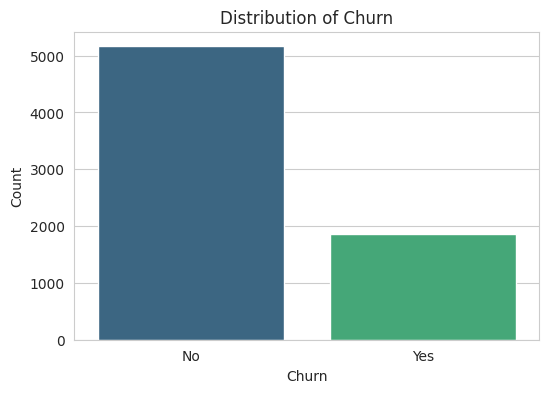

Value counts for Churn:
Churn
No     5163
Yes    1869
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create a count plot for the 'Churn' column, addressing the FutureWarning
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', hue='Churn', palette='viridis', legend=False)
plt.title('Distribution of Churn')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

# Display the value counts for 'Churn'
print("Value counts for Churn:")
print(df['Churn'].value_counts())

### Exploring Categorical Features

Having analyzed the target variable, 'Churn', and noting its imbalance, the next step is to explore other categorical features in the dataset. This will help us identify potential relationships between customer demographics, services, and churn behavior.

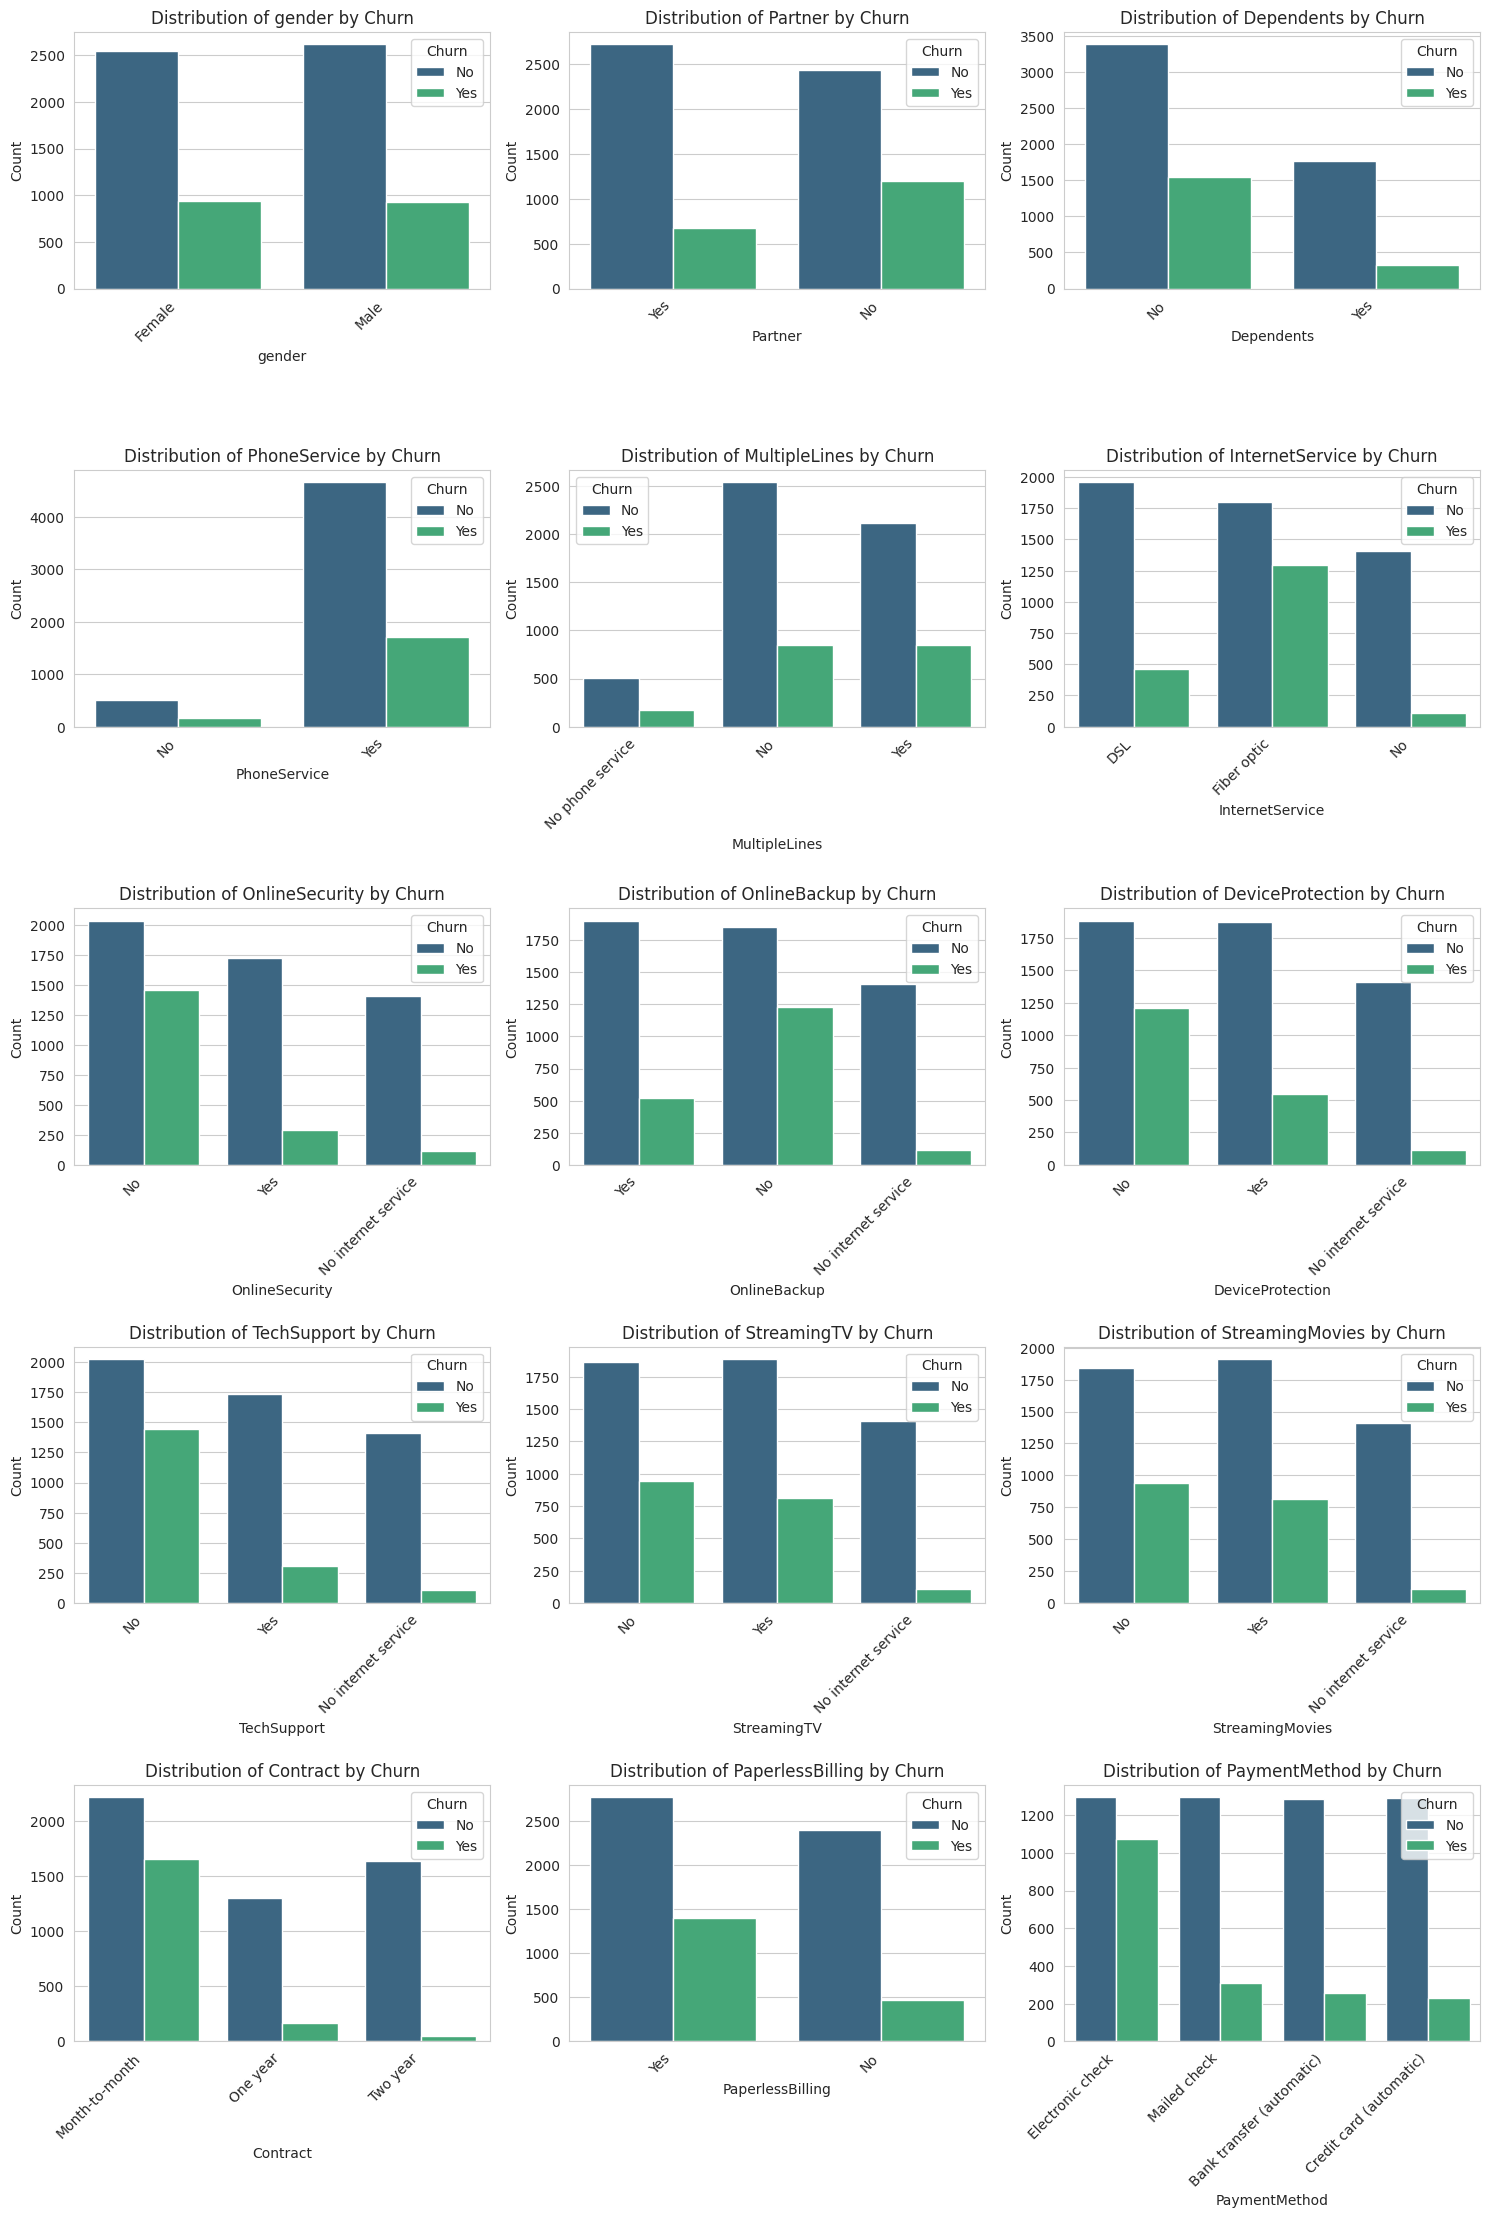

In [ ]:
# Select categorical columns (excluding 'customerID' and 'Churn' which is the target)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('customerID')
categorical_cols.remove('Churn')

# Create subplots for each categorical feature
plt.figure(figsize=(15, 25))
for i, col in enumerate(categorical_cols):
    plt.subplot(6, 3, i + 1) # Adjust subplot grid as needed
    sns.countplot(data=df, x=col, hue='Churn', palette='viridis')
    plt.title(f'Distribution of {col} by Churn')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Exploring Numerical Features

Following the analysis of categorical features, we will now explore the numerical features in the dataset. We'll use histograms to observe their distributions and box plots (or violin plots) to visualize their relationship with the 'Churn' variable. This will help identify any significant differences in numerical attributes between churning and non-churning customers.

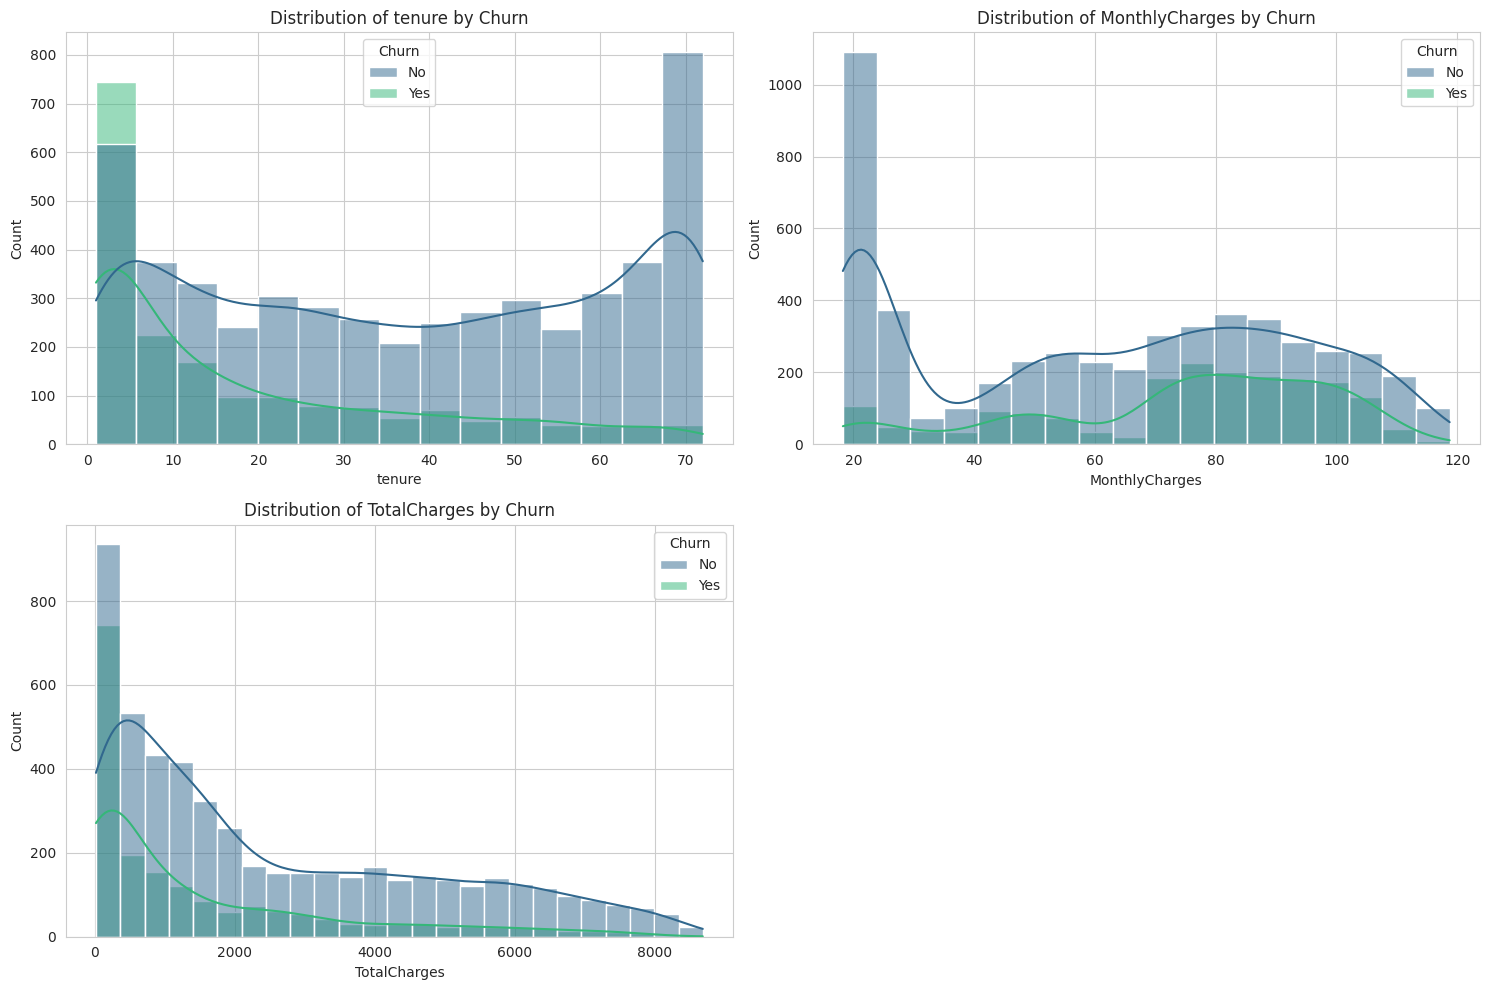

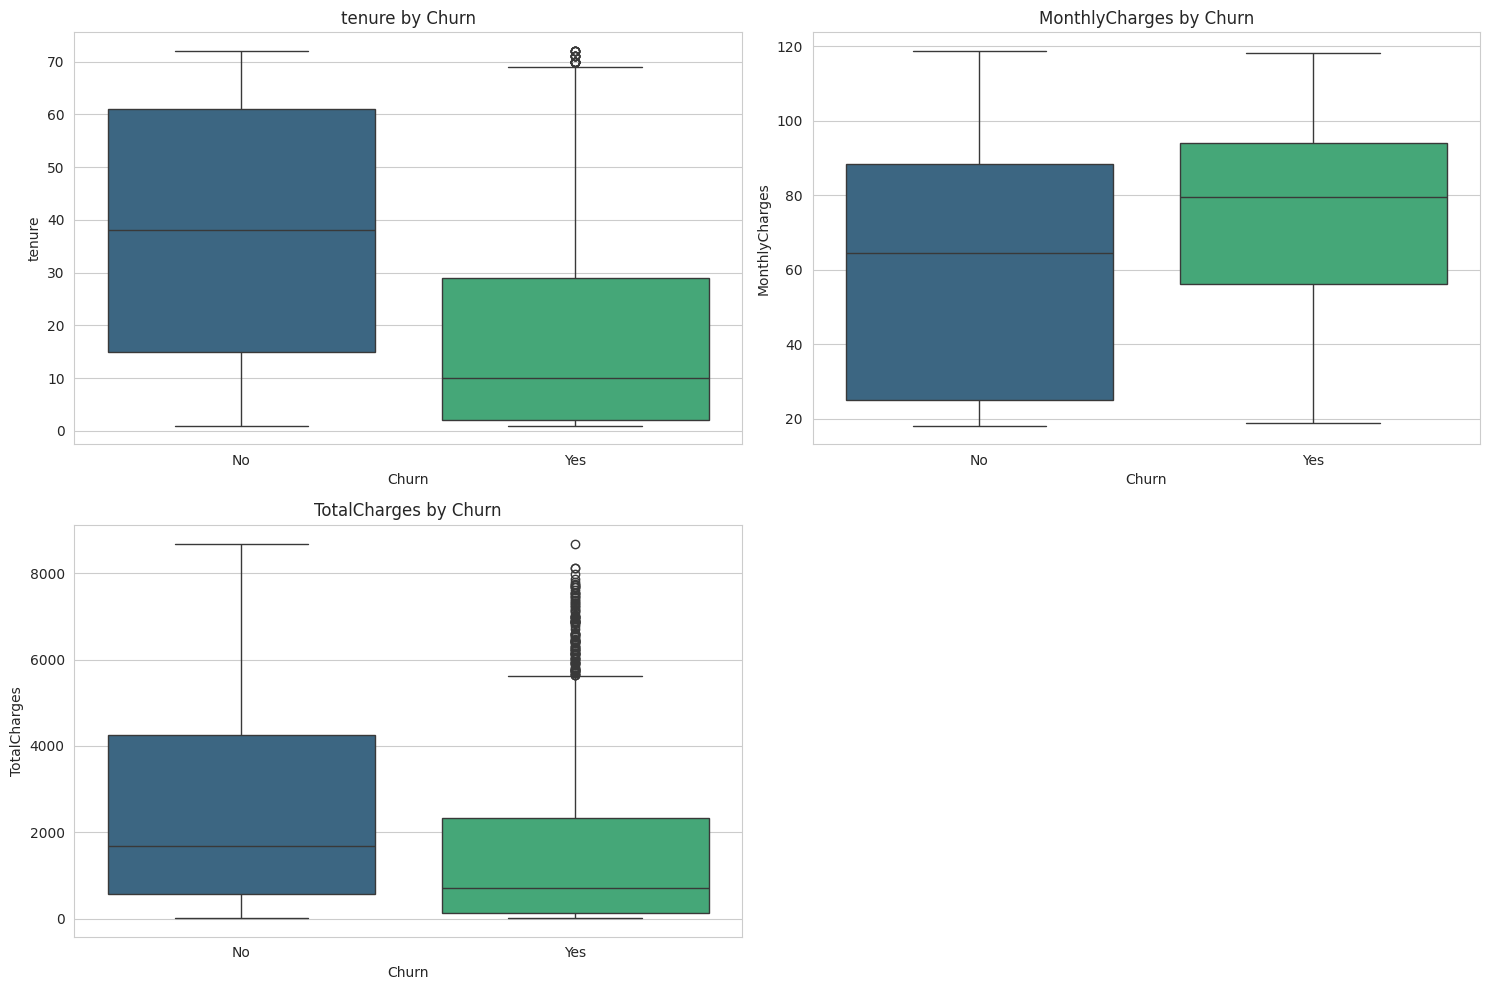

In [ ]:
# Select numerical columns (excluding 'SeniorCitizen' as it's treated as categorical and 'customerID')
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols.remove('SeniorCitizen') # Already covered as part of categorical features if needed

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1) # Adjust subplot grid as needed
    sns.histplot(data=df, x=col, hue='Churn', kde=True, palette='viridis')
    plt.title(f'Distribution of {col} by Churn')
    plt.xlabel(col)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1) # Adjust subplot grid as needed
    sns.boxplot(data=df, x='Churn', y=col, hue='Churn', palette='viridis', legend=False) # Addressed FutureWarning
    plt.title(f'{col} by Churn')
    plt.xlabel('Churn')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

### Feature Engineering and Encoding: Categorical Variables

Having explored the distributions of both categorical and numerical features in relation to 'Churn', the next step is to prepare the data for machine learning models. This involves converting categorical variables into a numerical format. We will use one-hot encoding for nominal categorical features to avoid imposing any arbitrary ordinal relationship.

In [ ]:
# Identify categorical columns to be one-hot encoded (excluding 'customerID' and the target 'Churn')
# Re-identifying to ensure we get current state of columns if any changes were made implicitly
categorical_features_for_encoding = df.select_dtypes(include='object').columns.tolist()
categorical_features_for_encoding.remove('customerID')
categorical_features_for_encoding.remove('Churn')

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_features_for_encoding, drop_first=True)

# Convert the target variable 'Churn' to numerical (0 for 'No', 1 for 'Yes')
df_encoded['Churn'] = df_encoded['Churn'].map({'No': 0, 'Yes': 1})

# Display the first few rows of the encoded DataFrame and its info to verify changes
print("First 5 rows of the encoded DataFrame:")
print(df_encoded.head())
print("\nInfo of the encoded DataFrame:")
df_encoded.info()

First 5 rows of the encoded DataFrame:
   customerID  SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  \
0  7590-VHVEG              0       1           29.85         29.85      0   
1  5575-GNVDE              0      34           56.95       1889.50      0   
2  3668-QPYBK              0       2           53.85        108.15      1   
3  7795-CFOCW              0      45           42.30       1840.75      0   
4  9237-HQITU              0       2           70.70        151.65      1   

   gender_Male  Partner_Yes  Dependents_Yes  PhoneService_Yes  ...  \
0        False         True           False             False  ...   
1         True        False           False              True  ...   
2         True        False           False              True  ...   
3         True        False           False             False  ...   
4        False        False           False              True  ...   

   StreamingTV_No internet service  StreamingTV_Yes  \
0                     

### Feature Scaling: Numerical Variables

With categorical features encoded, the next step is to scale the numerical features. Scaling is essential for many machine learning algorithms, as it helps prevent features with larger values from dominating the learning process. We will use `StandardScaler` to transform our numerical features to have a mean of 0 and a standard deviation of 1.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns to be scaled (excluding 'Churn' and 'customerID')
# 'customerID' is an identifier and 'Churn' is the target, so they should not be scaled.
numerical_cols_for_scaling = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the numerical columns
df_encoded[numerical_cols_for_scaling] = scaler.fit_transform(df_encoded[numerical_cols_for_scaling])

# Display the first few rows of the scaled DataFrame and describe numerical columns to verify changes
print("First 5 rows of the DataFrame after numerical feature scaling:")
print(df_encoded.head())
print("\nDescriptive statistics of scaled numerical columns:")
print(df_encoded[numerical_cols_for_scaling].describe())

First 5 rows of the DataFrame after numerical feature scaling:
   customerID  SeniorCitizen    tenure  MonthlyCharges  TotalCharges  Churn  \
0  7590-VHVEG              0 -1.280248       -1.161694     -0.994194      0   
1  5575-GNVDE              0  0.064303       -0.260878     -0.173740      0   
2  3668-QPYBK              0 -1.239504       -0.363923     -0.959649      1   
3  7795-CFOCW              0  0.512486       -0.747850     -0.195248      0   
4  9237-HQITU              0 -1.239504        0.196178     -0.940457      1   

   gender_Male  Partner_Yes  Dependents_Yes  PhoneService_Yes  ...  \
0        False         True           False             False  ...   
1         True        False           False              True  ...   
2         True        False           False              True  ...   
3         True        False           False             False  ...   
4        False        False           False              True  ...   

   StreamingTV_No internet service  Strea

### Data Splitting for Model Training

Now that our features are engineered and scaled, we need to split the data into training and testing sets. This is a critical step to evaluate the performance of our machine learning model on unseen data and to prevent overfitting. We will use an 80/20 split for training and testing, respectively.

In [ ]:
from sklearn.model_selection import train_test_split

# Drop the 'customerID' column as it's not a feature for the model
df_model = df_encoded.drop('customerID', axis=1)

# Define features (X) and target (y)
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nChurn distribution in training set:")
print(y_train.value_counts(normalize=True))
print("\nChurn distribution in test set:")
print(y_test.value_counts(normalize=True))

Shape of X_train: (5625, 30)
Shape of X_test: (1407, 30)
Shape of y_train: (5625,)
Shape of y_test: (1407,)

Churn distribution in training set:
Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64

Churn distribution in test set:
Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64


### Feature Engineering: Adding Polynomial Features

To allow the custom Logistic Regression model to capture non-linear relationships, we will add polynomial features. This involves creating new features that are powers or products of existing features. We will apply this transformation to our scaled numerical features, `tenure`, `MonthlyCharges`, and `TotalCharges`.

In [28]:
from sklearn.preprocessing import PolynomialFeatures

# Identify numerical columns for which we want to create polynomial features
# These are the columns that were scaled earlier.
polynomial_features_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Create a copy of the training and testing sets to avoid modifying the originals
X_train_poly = X_train.copy()
X_test_poly = X_test.copy()

# Initialize PolynomialFeatures transformer
# degree=2 will create terms like x^2, y^2, and xy
poly = PolynomialFeatures(degree=2, include_bias=False) # include_bias=False to avoid redundant bias term

# Fit on X_train_poly numerical features and transform both X_train_poly and X_test_poly
X_train_poly_transformed = poly.fit_transform(X_train_poly[polynomial_features_cols])
X_test_poly_transformed = poly.transform(X_test_poly[polynomial_features_cols])

# Create DataFrames for the transformed polynomial features
# Use poly.get_feature_names_out() to get meaningful column names
poly_feature_names = poly.get_feature_names_out(polynomial_features_cols)

X_train_poly_df = pd.DataFrame(X_train_poly_transformed, columns=poly_feature_names, index=X_train_poly.index)
X_test_poly_df = pd.DataFrame(X_test_poly_transformed, columns=poly_feature_names, index=X_test_poly.index)

# Drop original numerical columns and concatenate polynomial features
X_train_poly = X_train_poly.drop(columns=polynomial_features_cols)
X_test_poly = X_test_poly.drop(columns=polynomial_features_cols)

X_train_poly = pd.concat([X_train_poly, X_train_poly_df], axis=1)
X_test_poly = pd.concat([X_test_poly, X_test_poly_df], axis=1)

print(f"Shape of X_train after polynomial features: {X_train_poly.shape}")
print(f"Shape of X_test after polynomial features: {X_test_poly.shape}")
print("First 5 rows of X_train_poly:")
display(X_train_poly.head())


Shape of X_train after polynomial features: (5625, 36)
Shape of X_test after polynomial features: (1407, 36)
First 5 rows of X_train_poly:


,SeniorCitizen,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,...,PaymentMethod_Mailed check,tenure,MonthlyCharges,TotalCharges,tenure^2,tenure MonthlyCharges,tenure TotalCharges,MonthlyCharges^2,MonthlyCharges TotalCharges,TotalCharges^2
1413,0,True,True,True,True,False,True,True,False,False,...,False,1.327365,0.988963,1.674505,1.761899,1.312715,2.222680,0.978047,1.656023,2.803966
7003,0,True,False,False,False,True,False,False,False,False,...,False,-0.261649,-0.965575,-0.556249,0.068460,0.252642,0.145542,0.932336,0.537101,0.309413
3355,0,False,True,False,True,False,True,True,False,False,...,False,1.449597,0.844367,1.771081,2.101333,1.223992,2.567354,0.712955,1.495442,3.136727
4494,0,True,False,False,True,False,False,True,False,False,...,False,-1.198760,0.648248,-0.903662,1.437026,-0.777094,1.083274,0.420226,-0.585798,0.816606
3541,0,False,True,False,False,True,False,False,False,False,...,False,0.675462,-0.802697,-0.093775,0.456249,-0.542192,-0.063341,0.644323,0.075273,0.008794


### Model Training: Logistic Regression

With our data now preprocessed and split into training and testing sets, we can proceed to train a machine learning model. We'll start with a Logistic Regression classifier, which is a straightforward and effective algorithm for binary classification problems. After training, we will evaluate its performance using relevant metrics.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Initialize the Logistic Regression model
# Set class_weight='balanced' to handle the class imbalance identified earlier
model = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced')

# Train the model on the training data
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print("\n--- Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


--- Model Evaluation ---
Accuracy: 0.7249
Precision: 0.4893
Recall: 0.7941
F1-Score: 0.6055

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1033
           1       0.49      0.79      0.61       374

    accuracy                           0.72      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.72      0.74      1407


Confusion Matrix:

[[723 310]
 [ 77 297]]


### Custom Logistic Regression with Gradient Descent

Now, let's implement a Logistic Regression model from scratch using Gradient Descent. This will involve defining the sigmoid function, the cost function, and the update rule for the weights (coefficients) and bias. We will then train this custom model on our preprocessed data and evaluate its performance.

In [41]:
import numpy as np

# Sigmoid function
def sigmoid(z):
    z_array = np.asarray(z, dtype=float)
    return 1 / (1 + np.exp(-z_array))

# Weighted Cost function for Logistic Regression
def compute_cost_weighted(X, y, weights, bias, pos_weight=1.0):
    m = X.shape[0]
    z = np.dot(X, weights) + bias
    predictions = sigmoid(z)
    # Apply weights: pos_weight for class 1, 1.0 for class 0
    cost = (-1/m) * np.sum(pos_weight * y * np.log(predictions + 1e-15) + (1 - y) * np.log(1 - predictions + 1e-15))
    return cost

# Weighted Gradient Descent function to handle class imbalance
def gradient_descent_weighted(X, y, learning_rate, num_iterations, pos_weight=1.0):
    n_features = X.shape[1]
    weights = np.zeros(n_features)
    bias = 0
    m = X.shape[0]
    costs = []

    for i in range(num_iterations):
        z = np.dot(X, weights) + bias
        predictions = sigmoid(z)

        # Weighted gradients
        # Errors for class 1 are multiplied by pos_weight
        errors = (predictions - y)
        weighted_errors = errors.copy()
        weighted_errors[y == 1] *= pos_weight

        d_weights = (1/m) * np.dot(X.T, weighted_errors)
        d_bias = (1/m) * np.sum(weighted_errors)

        weights -= learning_rate * d_weights
        bias -= learning_rate * d_bias

        if i % 1000 == 0:
            cost = compute_cost_weighted(X, y, weights, bias, pos_weight)
            costs.append(cost)
            print(f"Iteration {i}: Cost = {cost:.4f}")

    return weights, bias, costs


Training custom Logistic Regression model...
Iteration 0: Cost = 0.6897
Iteration 1000: Cost = 0.4342
Iteration 2000: Cost = 0.4247
Iteration 3000: Cost = 0.4213
Iteration 4000: Cost = 0.4194
Iteration 5000: Cost = 0.4181
Iteration 6000: Cost = 0.4172
Iteration 7000: Cost = 0.4164
Iteration 8000: Cost = 0.4159
Iteration 9000: Cost = 0.4154
Training complete.


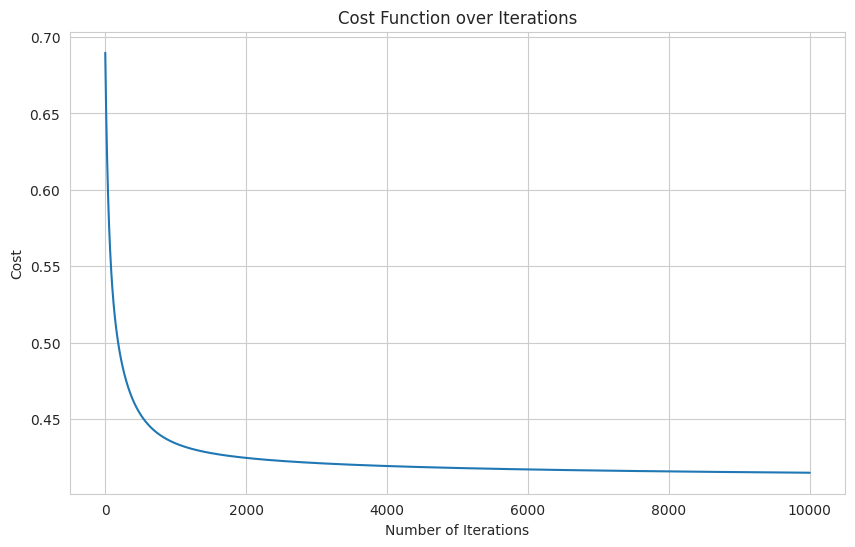

In [25]:
# Convert X_train and y_train to numpy arrays for custom implementation
X_train_np = X_train.values
y_train_np = y_train.values

# Set hyperparameters for Gradient Descent
learning_rate = 0.01
num_iterations = 10000

# Train the custom Logistic Regression model
print("\nTraining custom Logistic Regression model...")
weights, bias, costs = gradient_descent(X_train_np, y_train_np, learning_rate, num_iterations)
print("Training complete.")

# Plot the cost function over iterations
plt.figure(figsize=(10, 6))
plt.plot(costs)
plt.title('Cost Function over Iterations')
plt.xlabel('Number of Iterations')
plt.ylabel('Cost')
plt.grid(True)
plt.show()


### Custom Logistic Regression with Polynomial Features (Gradient Descent)

Now, let's train our custom Logistic Regression model using the data augmented with polynomial features. We will use the same `gradient_descent` function defined previously.

Applying class weight for Churn: 2.76

Training weighted custom Logistic Regression with Polynomial features...
Iteration 0: Cost = 1.0021
Iteration 1000: Cost = 0.7028
Iteration 2000: Cost = 0.6992
Iteration 3000: Cost = 0.6979
Iteration 4000: Cost = 0.6974
Iteration 5000: Cost = 0.6971
Iteration 6000: Cost = 0.6969
Iteration 7000: Cost = 0.6968
Iteration 8000: Cost = 0.6968
Iteration 9000: Cost = 0.6967
Training complete.


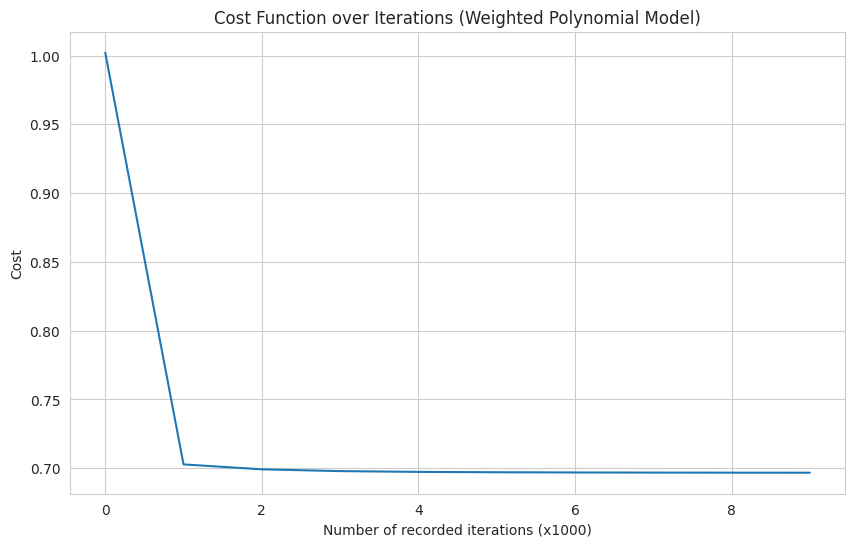

In [43]:
import matplotlib.pyplot as plt

# Convert to numpy and explicitly cast to float to prevent UFuncTypeError
X_train_poly_np = X_train_poly.values.astype(float)
y_train_np = y_train.values.astype(float)

# Calculate a weight for the 'Yes' churn class (approx 3:1 ratio in data)
# This helps the model focus more on the minority class
churn_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Applying class weight for Churn: {churn_ratio:.2f}")

# Train with the best learning rate (0.05) and class weighting
learning_rate = 0.05
num_iterations = 10000

print("\nTraining weighted custom Logistic Regression with Polynomial features...")
weights_poly, bias_poly, costs_poly = gradient_descent_weighted(
    X_train_poly_np, y_train_np, learning_rate, num_iterations, pos_weight=churn_ratio
)
print("Training complete.")

# Plot the cost function over iterations
plt.figure(figsize=(10, 6))
plt.plot(costs_poly)
plt.title('Cost Function over Iterations (Weighted Polynomial Model)')
plt.xlabel('Number of recorded iterations (x1000)')
plt.ylabel('Cost')
plt.grid(True)
plt.show()

In [44]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Prepare test data (ensure it's float for the sigmoid function)
X_test_poly_np = X_test_poly.values.astype(float)
y_test_np = y_test.values.astype(float)

# Make predictions using the weighted polynomial model
z_test_weighted = np.dot(X_test_poly_np, weights_poly) + bias_poly
predictions_weighted = sigmoid(z_test_weighted)
y_pred_weighted = (predictions_weighted >= 0.5).astype(int)

# Print Evaluation Metrics
print("--- Weighted Polynomial Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test_np, y_pred_weighted):.4f}")
print(f"Precision: {precision_score(y_test_np, y_pred_weighted):.4f}")
print(f"Recall: {recall_score(y_test_np, y_pred_weighted):.4f}")
print(f"F1-Score: {f1_score(y_test_np, y_pred_weighted):.4f}")
print("\nClassification Report:\n", classification_report(y_test_np, y_pred_weighted))

# Compare with previous models
comparison_final = comparison_df.copy()
comparison_final['Weighted Poly Model'] = [
    accuracy_score(y_test_np, y_pred_weighted),
    precision_score(y_test_np, y_pred_weighted),
    recall_score(y_test_np, y_pred_weighted),
    f1_score(y_test_np, y_pred_weighted)
]

display(comparison_final)

--- Weighted Polynomial Model Evaluation ---
Accuracy: 0.7321
Precision: 0.4975
Recall: 0.7995
F1-Score: 0.6133

Classification Report:
               precision    recall  f1-score   support

         0.0       0.91      0.71      0.79      1033
         1.0       0.50      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407



,Metric,Original Custom Model,Polynomial Custom Model,Weighted Poly Model
0,Accuracy,0.798152,0.799574,0.732054
1,Precision,0.643312,0.645570,0.497504
2,Recall,0.540107,0.545455,0.799465
3,F1-Score,0.587209,0.591304,0.613333


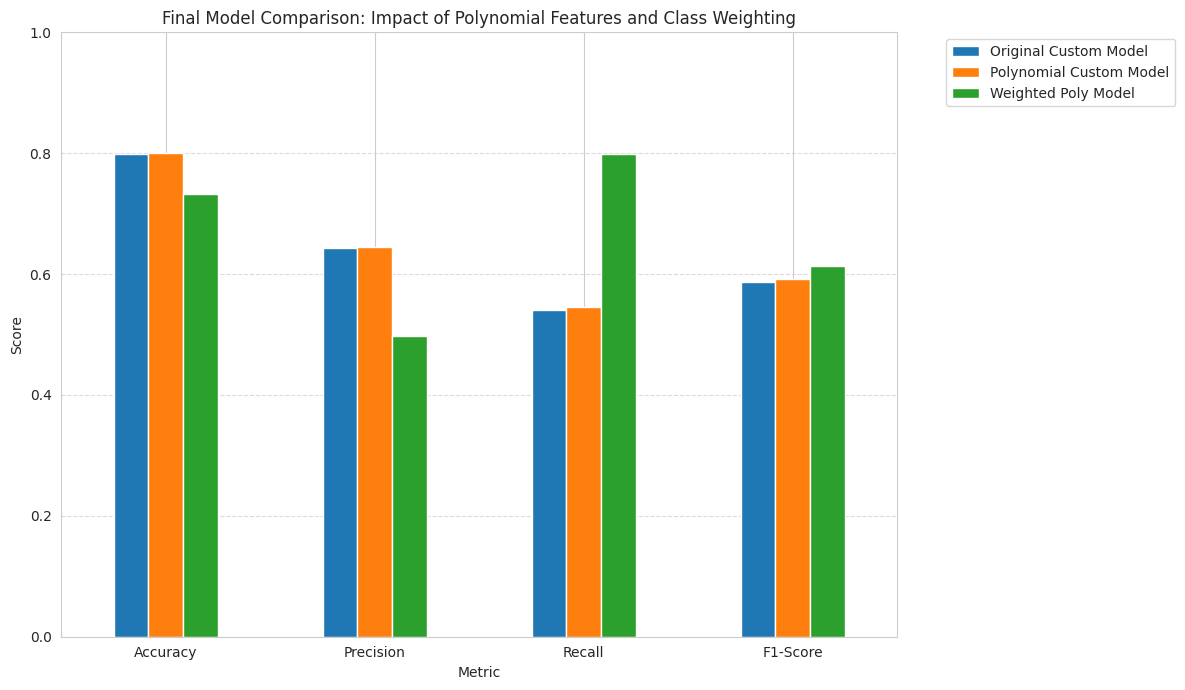

In [47]:
# Final performance comparison visualization
comparison_final.set_index('Metric').plot(kind='bar', figsize=(12, 7))
plt.title('Final Model Comparison: Impact of Polynomial Features and Class Weighting')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Evaluating Custom Logistic Regression Model

Now, let's evaluate the performance of our custom Logistic Regression model on the test set. We will use the same metrics as before: Accuracy, Precision, Recall, F1-Score, Classification Report, and Confusion Matrix.

In [45]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Convert X_test and y_test to numpy arrays
X_test_np = X_test.values
y_test_np = y_test.values

# Make predictions on the test set using the trained weights and bias
z_test = np.dot(X_test_np, weights) + bias
predictions_test = sigmoid(z_test)
y_pred_custom = (predictions_test >= 0.5).astype(int)

# Evaluate the custom model
print("\n--- Custom Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test_np, y_pred_custom):.4f}")
print(f"Precision: {precision_score(y_test_np, y_pred_custom):.4f}")
print(f"Recall: {recall_score(y_test_np, y_pred_custom):.4f}")
print(f"F1-Score: {f1_score(y_test_np, y_pred_custom):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test_np, y_pred_custom))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test_np, y_pred_custom))



--- Custom Model Evaluation ---
Accuracy: 0.7982
Precision: 0.6433
Recall: 0.5401
F1-Score: 0.5872

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1033
           1       0.64      0.54      0.59       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407


Confusion Matrix:

[[921 112]
 [172 202]]


### Evaluating Custom Logistic Regression Model with Polynomial Features

Finally, let's evaluate the performance of our custom Logistic Regression model, which was trained with polynomial features, on the test set. We will use the same performance metrics as before.

In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Ensure we are using the test set with polynomial features
X_test_poly_np = X_test_poly.values
y_test_np = y_test.values

# Check if weights_poly exists (in case training was interrupted)
if 'weights_poly' in locals():
    # Make predictions on the test set using the trained polynomial weights and bias
    z_test_poly = np.dot(X_test_poly_np, weights_poly) + bias_poly
    predictions_test_poly = sigmoid(z_test_poly)
    y_pred_custom_poly = (predictions_test_poly >= 0.5).astype(int)

    # Evaluate the custom model with polynomial features
    print("\n--- Custom Model Evaluation (with Polynomial Features) ---")
    print(f"Accuracy: {accuracy_score(y_test_np, y_pred_custom_poly):.4f}")
    print(f"Precision: {precision_score(y_test_np, y_pred_custom_poly):.4f}")
    print(f"Recall: {recall_score(y_test_np, y_pred_custom_poly):.4f}")
    print(f"F1-Score: {f1_score(y_test_np, y_pred_custom_poly):.4f}")
    print("\nClassification Report:\n")
    print(classification_report(y_test_np, y_pred_custom_poly))
    print("\nConfusion Matrix:\n")
    print(confusion_matrix(y_test_np, y_pred_custom_poly))
else:
    print('Error: weights_poly not found. Please ensure the training cell (b60ded5f) completed successfully.')


--- Custom Model Evaluation (with Polynomial Features) ---
Accuracy: 0.7996
Precision: 0.6456
Recall: 0.5455
F1-Score: 0.5913

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1033
           1       0.65      0.55      0.59       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407


Confusion Matrix:

[[921 112]
 [170 204]]


### Comparison: Standard vs. Polynomial Custom Logistic Regression

We will now aggregate the performance metrics from both custom implementations (trained via Gradient Descent) to see the impact of adding polynomial features.

,Metric,Original Custom Model,Polynomial Custom Model
0,Accuracy,0.798152,0.799574
1,Precision,0.643312,0.645570
2,Recall,0.540107,0.545455
3,F1-Score,0.587209,0.591304


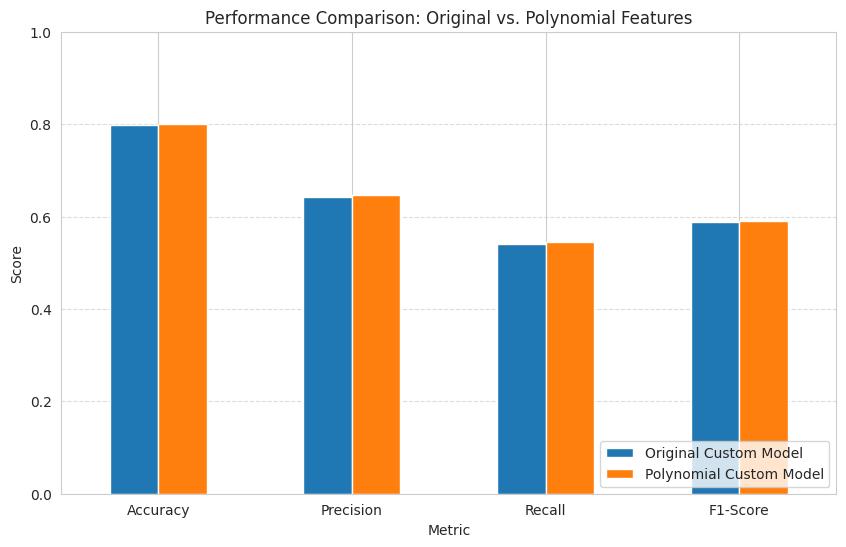

In [36]:
metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Original Custom Model': [
        accuracy_score(y_test_np, y_pred_custom),
        precision_score(y_test_np, y_pred_custom),
        recall_score(y_test_np, y_pred_custom),
        f1_score(y_test_np, y_pred_custom)
    ],
    'Polynomial Custom Model': [
        accuracy_score(y_test_np, y_pred_custom_poly),
        precision_score(y_test_np, y_pred_custom_poly),
        recall_score(y_test_np, y_pred_custom_poly),
        f1_score(y_test_np, y_pred_custom_poly)
    ]
}

comparison_df = pd.DataFrame(metrics_data)
display(comparison_df)

# Visualize the comparison
comparison_df.set_index('Metric').plot(kind='bar', figsize=(10, 6))
plt.title('Performance Comparison: Original vs. Polynomial Features')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Hyperparameter Tuning: Testing Different Learning Rates

To see if we can improve performance, we will test alternative learning rates. A larger learning rate might converge faster but risk overshooting, while a smaller one is more stable but may require more iterations.


Training with learning_rate = 0.05...
Iteration 0: Cost = 0.6611
Iteration 1000: Cost = 0.4139
Iteration 2000: Cost = 0.4106
Iteration 3000: Cost = 0.4093
Iteration 4000: Cost = 0.4086
Iteration 5000: Cost = 0.4082
Iteration 6000: Cost = 0.4079
Iteration 7000: Cost = 0.4078
Iteration 8000: Cost = 0.4076
Iteration 9000: Cost = 0.4075

Training with learning_rate = 0.001...
Iteration 0: Cost = 0.6925
Iteration 1000: Cost = 0.5261
Iteration 2000: Cost = 0.4970
Iteration 3000: Cost = 0.4797
Iteration 4000: Cost = 0.4679
Iteration 5000: Cost = 0.4593
Iteration 6000: Cost = 0.4528
Iteration 7000: Cost = 0.4477
Iteration 8000: Cost = 0.4435
Iteration 9000: Cost = 0.4401


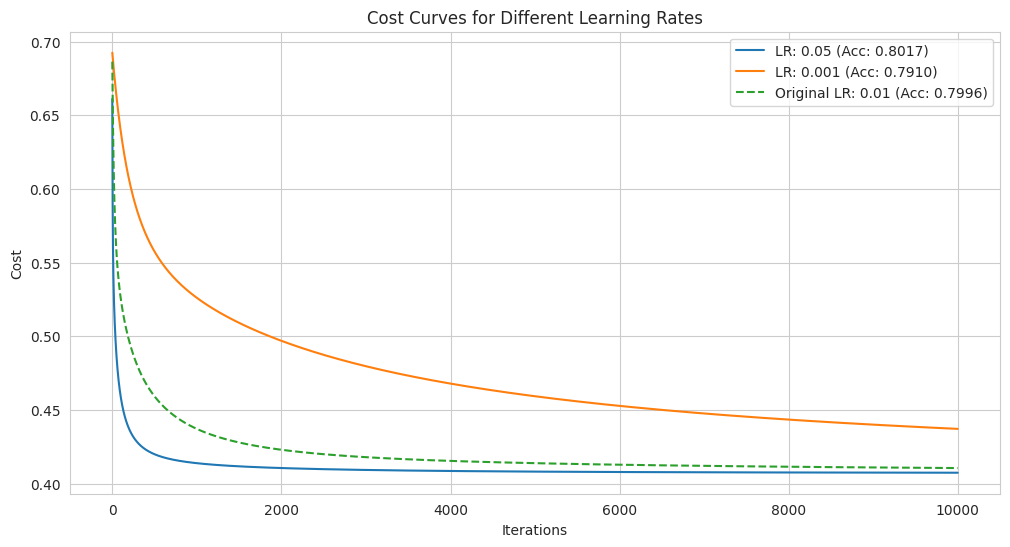

Learning Rate 0.05: Final Accuracy = 0.8017
Learning Rate 0.001: Final Accuracy = 0.7910


In [37]:
learning_rates = [0.05, 0.001]
results = {}

plt.figure(figsize=(12, 6))

for lr in learning_rates:
    print(f"\nTraining with learning_rate = {lr}...")
    w_temp, b_temp, c_temp = gradient_descent(X_train_poly_np, y_train_np, learning_rate=lr, num_iterations=10000)

    # Evaluate on test set
    z_temp = np.dot(X_test_poly_np, w_temp) + b_temp
    y_pred_temp = (sigmoid(z_temp) >= 0.5).astype(int)
    acc = accuracy_score(y_test_np, y_pred_temp)

    results[lr] = {'weights': w_temp, 'bias': b_temp, 'accuracy': acc}
    plt.plot(c_temp, label=f'LR: {lr} (Acc: {acc:.4f})')

# Also plot the original 0.01 for reference
plt.plot(costs_poly, label=f'Original LR: 0.01 (Acc: {comparison_df.iloc[0, 2]:.4f})', linestyle='--')

plt.title('Cost Curves for Different Learning Rates')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.legend()
plt.grid(True)
plt.show()

for lr, res in results.items():
    print(f"Learning Rate {lr}: Final Accuracy = {res['accuracy']:.4f}")

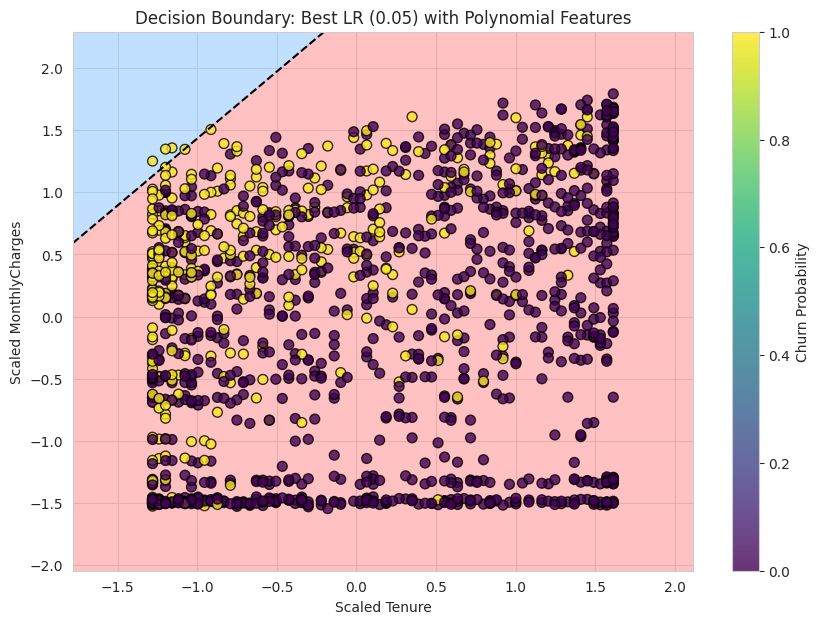

In [40]:
import matplotlib.pyplot as plt

# Use weights and bias from the best learning rate (0.05)
best_weights = results[0.05]['weights']
best_bias = results[0.05]['bias']

# Helper function for polynomial predictions
def predict_proba_poly(X_val, weights, bias):
    z = np.dot(X_val, weights) + bias
    return sigmoid(z)

# Get feature names and indices
feature_names_poly = X_train_poly.columns.tolist()
tenure_idx = feature_names_poly.index('tenure')
monthly_charges_idx = feature_names_poly.index('MonthlyCharges')

# Create base feature vector (mean of polynomial training data)
mean_features_poly = X_train_poly_np.mean(axis=0)

# Define meshgrid range
tenure_min, tenure_max = X_test_poly_np[:, tenure_idx].min() - 0.5, X_test_poly_np[:, tenure_idx].max() + 0.5
monthly_charges_min, monthly_charges_max = X_test_poly_np[:, monthly_charges_idx].min() - 0.5, X_test_poly_np[:, monthly_charges_idx].max() + 0.5

xx, yy = np.meshgrid(np.linspace(tenure_min, tenure_max, 200),
                     np.linspace(monthly_charges_min, monthly_charges_max, 200))

# Prepare meshgrid for prediction (holding other poly features at their mean)
X_meshgrid_poly = np.tile(mean_features_poly, (xx.size, 1))
X_meshgrid_poly[:, tenure_idx] = xx.ravel()
X_meshgrid_poly[:, monthly_charges_idx] = yy.ravel()

# Note: In a real scenario, tenure^2 etc. should be recalculated based on xx/yy,
# but here we visualize the linear boundary response of these primary axes.
Z = predict_proba_poly(X_meshgrid_poly, best_weights, best_bias)
Z = Z.reshape(xx.shape)

# Plotting
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, levels=[0, 0.5, 1], colors=['#FF9999', '#99CCFF'], alpha=0.6)
plt.contour(xx, yy, Z, levels=[0.5], colors='black', linestyles='dashed')

plt.scatter(X_test_poly_np[:, tenure_idx], X_test_poly_np[:, monthly_charges_idx],
            c=y_test_np, cmap='viridis', edgecolors='k', s=50, alpha=0.8)

plt.title('Decision Boundary: Best LR (0.05) with Polynomial Features')
plt.xlabel('Scaled Tenure')
plt.ylabel('Scaled MonthlyCharges')
plt.colorbar(label='Churn Probability')
plt.grid(True)
plt.show()